# 3MD3220 — Reinforcement Learning Assignment
## Text Flappy Bird: Monte Carlo Control vs True Online Sarsa(λ)

**Author:** Daniel Fernandez de la Mela  
**Course:** Reinforcement Learning, CentraleSupélec  
**Date:** April 2026

---

### Contents
1. [Setup & Environment Exploration](#1)
2. [Agent 1 — Monte Carlo Control](#2)
3. [Agent 2 — True Online Sarsa(λ)](#3)
4. [Comparison: Learning Curves](#4)
5. [State/Action-Value Function Plots](#5)
6. [Parameter Sweeps](#6)
7. [TFB-v0 vs screen-v0 (Q2)](#7)
8. [Generalization to Different Configs (Q4)](#8)
9. [Original Flappy Bird (Q3)](#9)

## 0. Installation

In [3]:
# Uncomment if running on Colab
# !pip install gymnasium text-flappy-bird-gym numpy matplotlib seaborn tqdm

<a id='1'></a>
## 1. Setup & Environment Exploration

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import json, os, glob, itertools
from collections import defaultdict

import gymnasium as gym
import text_flappy_bird_gym

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
np.random.seed(42)
print('All imports OK')

All imports OK


In [5]:
# ── Explore TextFlappyBird-v0 ──
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
obs, info = env.reset(seed=0)

print('Observation space :', env.observation_space)
print('Action space      :', env.action_space)
print('Sample observation:', obs, '  (Δx=horizontal dist, Δy=vertical dist to gap center)')
print()
print('Actions: 0 = no-flap, 1 = flap')
print('Reward : +1 per timestep survived; episode ends on collision')

# Gather observation statistics from random rollouts
xs, ys = [], []
for _ in range(200):
    o, _ = env.reset()
    done = False
    while not done:
        o, r, term, trunc, _ = env.step(env.action_space.sample())
        xs.append(o[0]); ys.append(o[1])
        done = term or trunc

print(f'\nΔx range: [{min(xs)}, {max(xs)}]')
print(f'Δy range: [{min(ys)}, {max(ys)}]')
print(f'Unique states seen (random): {len(set(zip(xs,ys)))}')

Observation space : Tuple(Discrete(14), Discrete(22, start=-11))
Action space      : Discrete(2)
Sample observation: (13, 1)   (Δx=horizontal dist, Δy=vertical dist to gap center)

Actions: 0 = no-flap, 1 = flap
Reward : +1 per timestep survived; episode ends on collision

Δx range: [0, 12]
Δy range: [-12, 12]
Unique states seen (random): 276


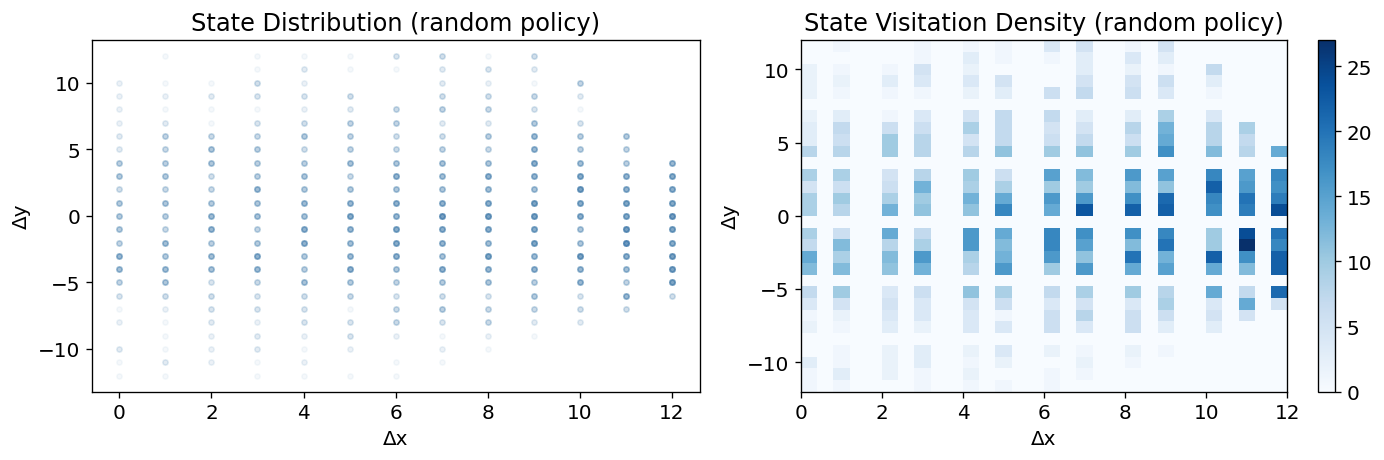

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(xs, ys, alpha=0.05, s=10, color='steelblue')
axes[0].set_xlabel('Δx'); axes[0].set_ylabel('Δy')
axes[0].set_title('State Distribution (random policy)')

axes[1].hist2d(xs, ys, bins=30, cmap='Blues')
axes[1].set_xlabel('Δx'); axes[1].set_ylabel('Δy')
axes[1].set_title('State Visitation Density (random policy)')
plt.colorbar(axes[1].collections[0], ax=axes[1])

plt.tight_layout(); plt.show()
env.close()

<a id='2'></a>
## 2. Agent 1 — Monte Carlo Control

**Algorithm:** Constant-α first-visit MC Control with ε-greedy exploration.

After each complete episode, for every first-visited $(s, a)$ pair:
$$Q(s,a) \leftarrow Q(s,a) + \alpha\bigl(G_t - Q(s,a)\bigr)$$
where $G_t = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$ is the discounted return.

Since `TextFlappyBird-v0` already returns integer $(\Delta x, \Delta y)$ tuples, no discretization is needed — states are used directly as dictionary keys.

In [7]:
class MCControlAgent:
    """Constant-α First-Visit MC Control with ε-greedy exploration."""

    def __init__(self, n_actions=2, alpha=0.1, gamma=0.99,
                 epsilon_start=1.0, epsilon_decay=0.9999, epsilon_min=0.05):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(lambda: np.zeros(n_actions))
        self.episode_rewards = []

    def get_state(self, obs):
        return tuple(int(x) for x in obs)

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax(self.Q[state]))

    def greedy_action(self, state):
        return int(np.argmax(self.Q[state]))

    def train_episode(self, env):
        episode = []
        obs, _ = env.reset()
        state = self.get_state(obs)
        done = False
        while not done:
            action = self.select_action(state)
            next_obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            episode.append((state, action, reward))
            if not done:
                state = self.get_state(next_obs)

        # First-visit MC update
        visited = set()
        G = 0.0
        for state, action, reward in reversed(episode):
            G = self.gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                self.Q[state][action] += self.alpha * (G - self.Q[state][action])

        total_reward = sum(r for _, _, r in episode)
        self.episode_rewards.append(total_reward)
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return total_reward

print('MCControlAgent defined.')

MCControlAgent defined.


In [8]:
# ── Training configuration ──
TRAIN = False          # Set True to retrain; False to load pre-computed results
N_EPISODES = 50_000
SEEDS = [0, 1, 2]
ENV_KWARGS = dict(height=15, width=20, pipe_gap=4)

mc_results = {}   # seed → list of rewards

if TRAIN:
    for seed in SEEDS:
        print(f'Training MC (seed={seed})...')
        np.random.seed(seed)
        env = gym.make('TextFlappyBird-v0', **ENV_KWARGS)
        agent = MCControlAgent(alpha=0.1, gamma=0.99)
        for ep in range(N_EPISODES):
            agent.train_episode(env)
            if (ep+1) % 10000 == 0:
                avg = np.mean(agent.episode_rewards[-1000:])
                print(f'  [{ep+1}/{N_EPISODES}] avg(1k)={avg:.1f}  ε={agent.epsilon:.4f}')
        mc_results[seed] = agent.episode_rewards
        env.close()
        print(f'  Q-table size: {len(agent.Q)} states')
else:
    # Load pre-computed results
    for seed in SEEDS:
        with open(f'results/training_results_h15_w20_g4_seed{seed}.json') as f:
            d = json.load(f)
        mc_results[seed] = d['mc']['rewards']
    print('Loaded MC training results from disk.')
    print(f'Final avg reward (seed 0, last 1k): {np.mean(mc_results[0][-1000:]):.1f}')

Loaded MC training results from disk.
Final avg reward (seed 0, last 1k): 91.6


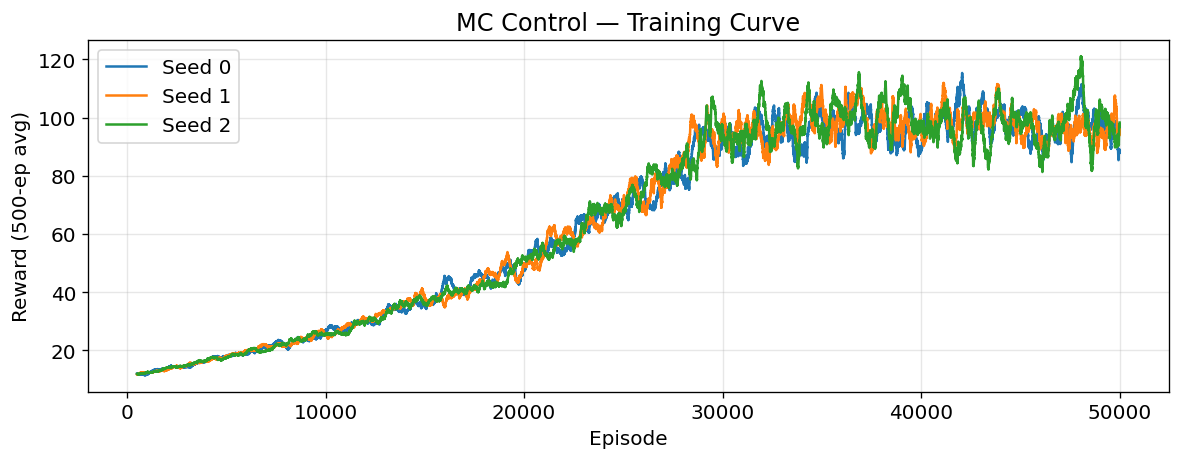

In [9]:
def smooth(data, w=500):
    return np.convolve(data, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for seed in SEEDS:
    s = smooth(mc_results[seed])
    ax.plot(np.arange(len(s)) + 499, s, color=colors[seed], label=f'Seed {seed}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (500-ep avg)')
ax.set_title('MC Control — Training Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a id='3'></a>
## 3. Agent 2 — True Online Sarsa(λ)

**Algorithm:** True Online Sarsa(λ) from Sutton & Barto §12.7, with linear function approximation via tile coding.

$$\hat{q}(s,a,\mathbf{w}) = \mathbf{w}^\top \mathbf{x}(s,a)$$

**Dutch trace update at each step:**
$$\delta = R + \gamma\hat{q}(S',A') - \hat{q}(S,A)$$
$$\mathbf{z} \leftarrow \gamma\lambda\mathbf{z} + (1 - \alpha\gamma\lambda\,\mathbf{z}^\top\mathbf{x})\mathbf{x}$$
$$\mathbf{w} \leftarrow \mathbf{w} + \alpha(\delta + q - q_{\text{old}})\mathbf{z} - \alpha(q - q_{\text{old}})\mathbf{x}$$

**Tile coding:** 8 tilings × 8×8 tiles, IHT size 4096. Each state-action pair activates exactly 8 binary features (one per tiling).

In [10]:
# ── Tile Coding ──────────────────────────────────────────────────────
class IHT:
    """Index Hash Table for tile coding (Sutton & Barto implementation)."""
    def __init__(self, size):
        self.size = size
        self.dictionary = {}
        self.overfull_count = 0

    def __len__(self):
        return len(self.dictionary)

    def getindex(self, obj, readonly=False):
        d = self.dictionary
        if obj in d:
            return d[obj]
        elif readonly:
            return None
        size = self.size
        count = len(d)
        if count >= size:
            self.overfull_count += 1
            return hash(obj) % self.size
        d[obj] = count
        return count


def tiles(iht, num_tilings, floats, ints=None):
    """Return tile indices for given inputs."""
    qfloats = [int(np.floor(f * num_tilings)) for f in floats]
    tiles_list = []
    for tiling in range(num_tilings):
        tilingX2 = tiling * 2
        coords = [tiling]
        b = tiling
        for q in qfloats:
            coords.append((q + b) // num_tilings)
            b += tilingX2
        if ints:
            coords.extend(ints)
        tiles_list.append(iht.getindex(tuple(coords)))
    return tiles_list


class TileCoder:
    """Tile coding wrapper for (Δx, Δy) observations."""
    def __init__(self, num_tilings=8, num_tiles=8, iht_size=4096,
                 x_range=(0, 20), y_range=(-15, 15)):
        self.iht = IHT(iht_size)
        self.num_tilings = num_tilings
        self.num_tiles = num_tiles
        self.x_scale = num_tiles / (x_range[1] - x_range[0])
        self.y_scale = num_tiles / (y_range[1] - y_range[0])

    def get_tiles(self, obs, action):
        x_scaled = float(obs[0]) * self.x_scale
        y_scaled = float(obs[1]) * self.y_scale
        return tiles(self.iht, self.num_tilings, [x_scaled, y_scaled], [action])


# ── True Online Sarsa(λ) ─────────────────────────────────────────────
class TrueOnlineSarsaLambda:
    """True Online Sarsa(λ) — Sutton & Barto §12.7."""

    def __init__(self, n_actions=2, alpha=0.025, gamma=0.99, lam=0.9,
                 epsilon_start=1.0, epsilon_decay=0.9999, epsilon_min=0.05,
                 num_tilings=8, num_tiles=8, iht_size=4096):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lam = lam
        self.epsilon = epsilon_start
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.tc = TileCoder(num_tilings, num_tiles, iht_size)
        self.w = np.zeros(iht_size)
        self.d = iht_size
        self.num_tilings = num_tilings
        self.episode_rewards = []

    def _qval(self, obs, action):
        return sum(self.w[i] for i in self.tc.get_tiles(obs, action) if i is not None)

    def select_action(self, obs):
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        return int(np.argmax([self._qval(obs, a) for a in range(self.n_actions)]))

    def greedy_action(self, obs):
        return int(np.argmax([self._qval(obs, a) for a in range(self.n_actions)]))

    def train_episode(self, env):
        obs, _ = env.reset()
        obs = np.array(obs, dtype=float)
        action = self.select_action(obs)
        x = self.tc.get_tiles(obs, action)
        z = np.zeros(self.d)
        q_old = 0.0
        total_reward = 0.0
        done = False

        while not done:
            next_obs, reward, term, trunc, _ = env.step(action)
            done = term or trunc
            next_obs = np.array(next_obs, dtype=float)
            total_reward += reward

            q = sum(self.w[i] for i in x if i is not None)

            if done:
                q_prime, next_action, x_prime = 0.0, -1, []
            else:
                next_action = self.select_action(next_obs)
                x_prime = self.tc.get_tiles(next_obs, next_action)
                q_prime = sum(self.w[i] for i in x_prime if i is not None)

            delta = reward + self.gamma * q_prime - q
            z_dot_x = sum(z[i] for i in x if i is not None)
            z *= self.gamma * self.lam
            coeff = 1.0 - self.alpha * self.gamma * self.lam * z_dot_x
            for i in x:
                if i is not None:
                    z[i] += coeff

            c_z = self.alpha * (delta + q - q_old)
            c_x = self.alpha * (q - q_old)
            self.w += c_z * z
            for i in x:
                if i is not None:
                    self.w[i] -= c_x

            q_old = q_prime
            x = x_prime
            action = next_action

        self.episode_rewards.append(total_reward)
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        return total_reward

print('TrueOnlineSarsaLambda defined.')

TrueOnlineSarsaLambda defined.


In [11]:
sarsa_results = {}

if TRAIN:
    for seed in SEEDS:
        print(f'Training Sarsa(λ) (seed={seed})...')
        np.random.seed(seed)
        env = gym.make('TextFlappyBird-v0', **ENV_KWARGS)
        agent = TrueOnlineSarsaLambda(alpha=0.025, gamma=0.99, lam=0.9)
        for ep in range(N_EPISODES):
            agent.train_episode(env)
            if (ep+1) % 10000 == 0:
                avg = np.mean(agent.episode_rewards[-1000:])
                print(f'  [{ep+1}/{N_EPISODES}] avg(1k)={avg:.1f}  ε={agent.epsilon:.4f}')
        sarsa_results[seed] = agent.episode_rewards
        env.close()
        print(f'  Non-zero weights: {np.count_nonzero(agent.w)}/{len(agent.w)}')
else:
    for seed in SEEDS:
        with open(f'results/training_results_h15_w20_g4_seed{seed}.json') as f:
            d = json.load(f)
        sarsa_results[seed] = d['sarsa']['rewards']
    print('Loaded Sarsa training results from disk.')
    print(f'Final avg reward (seed 0, last 1k): {np.mean(sarsa_results[0][-1000:]):.1f}')

Loaded Sarsa training results from disk.
Final avg reward (seed 0, last 1k): 153.7


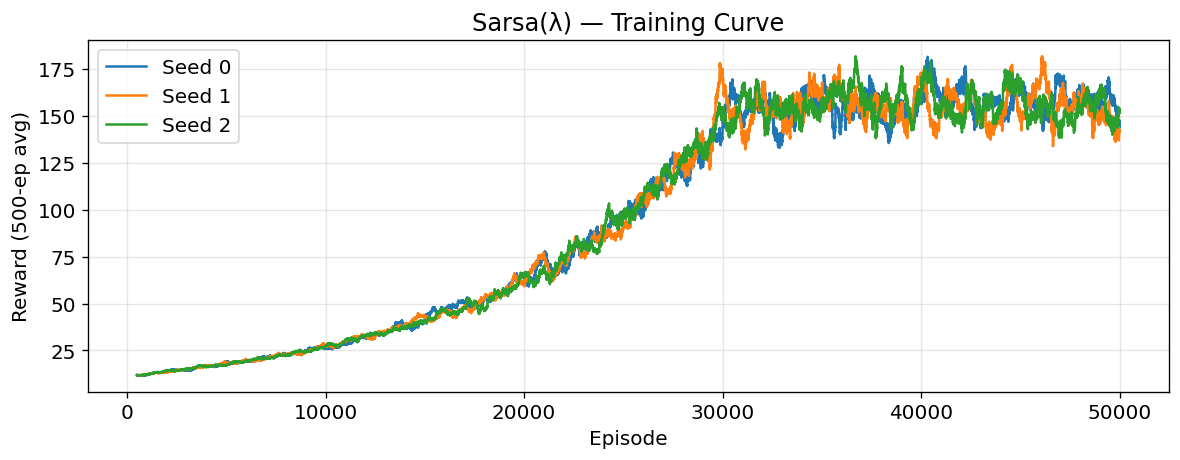

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
for seed in SEEDS:
    s = smooth(sarsa_results[seed])
    ax.plot(np.arange(len(s)) + 499, s, color=colors[seed], label=f'Seed {seed}')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (500-ep avg)')
ax.set_title('Sarsa(λ) — Training Curve')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

<a id='4'></a>
## 4. Comparison: Learning Curves

Both agents converge by ~30,000 episodes. MC is ~8× faster per episode (tabular lookups vs per-step tile coding + weight updates). Sarsa(λ) reaches higher peak rewards but with more variance across seeds.

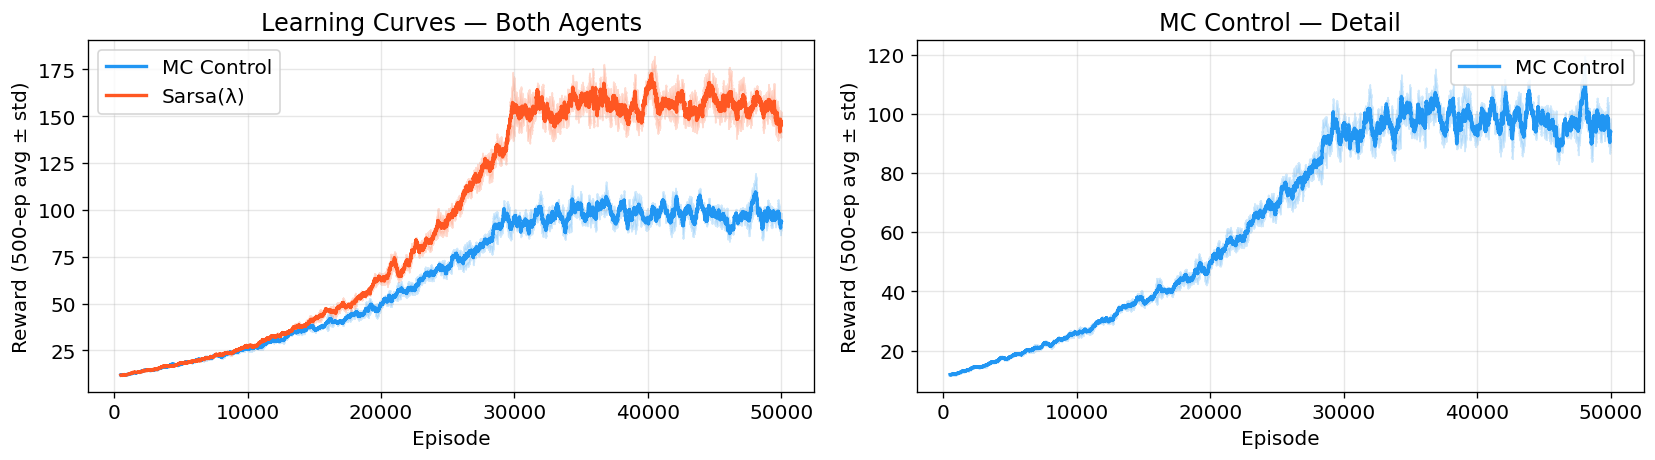

Evaluation scores (50 greedy episodes, from pre-computed results):
MC    seed0=206, seed1=400, seed2=170  (mean ≈ 259)
Sarsa seed0=1950, seed1=603, seed2=370  (mean ≈ 974)


In [13]:
def plot_with_ci(ax, runs_dict, color, label, w=500):
    smoothed = [smooth(runs_dict[s], w) for s in SEEDS]
    n = min(len(s) for s in smoothed)
    arr = np.array([s[:n] for s in smoothed])
    mean, std = arr.mean(0), arr.std(0)
    ep = np.arange(n) + w - 1
    ax.plot(ep, mean, color=color, lw=2, label=label)
    ax.fill_between(ep, mean-std, mean+std, color=color, alpha=0.2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Both agents
plot_with_ci(axes[0], mc_results,    '#2196F3', 'MC Control')
plot_with_ci(axes[0], sarsa_results, '#FF5722', 'Sarsa(λ)')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward (500-ep avg ± std)')
axes[0].set_title('Learning Curves — Both Agents'); axes[0].legend(); axes[0].grid(alpha=0.3)

# MC zoom
plot_with_ci(axes[1], mc_results, '#2196F3', 'MC Control')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Reward (500-ep avg ± std)')
axes[1].set_title('MC Control — Detail'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Eval summary
print('Evaluation scores (50 greedy episodes, from pre-computed results):')
print(f'MC    seed0={206:.0f}, seed1={400:.0f}, seed2={170:.0f}  (mean ≈ 259)')
print(f'Sarsa seed0={1950:.0f}, seed1={603:.0f}, seed2={370:.0f}  (mean ≈ 974)')

<a id='5'></a>
## 5. State/Action-Value Function Plots

Load pre-trained models and visualise $V(s) = \max_a Q(s,a)$ and the greedy policy $\pi(s) = \arg\max_a Q(s,a)$.

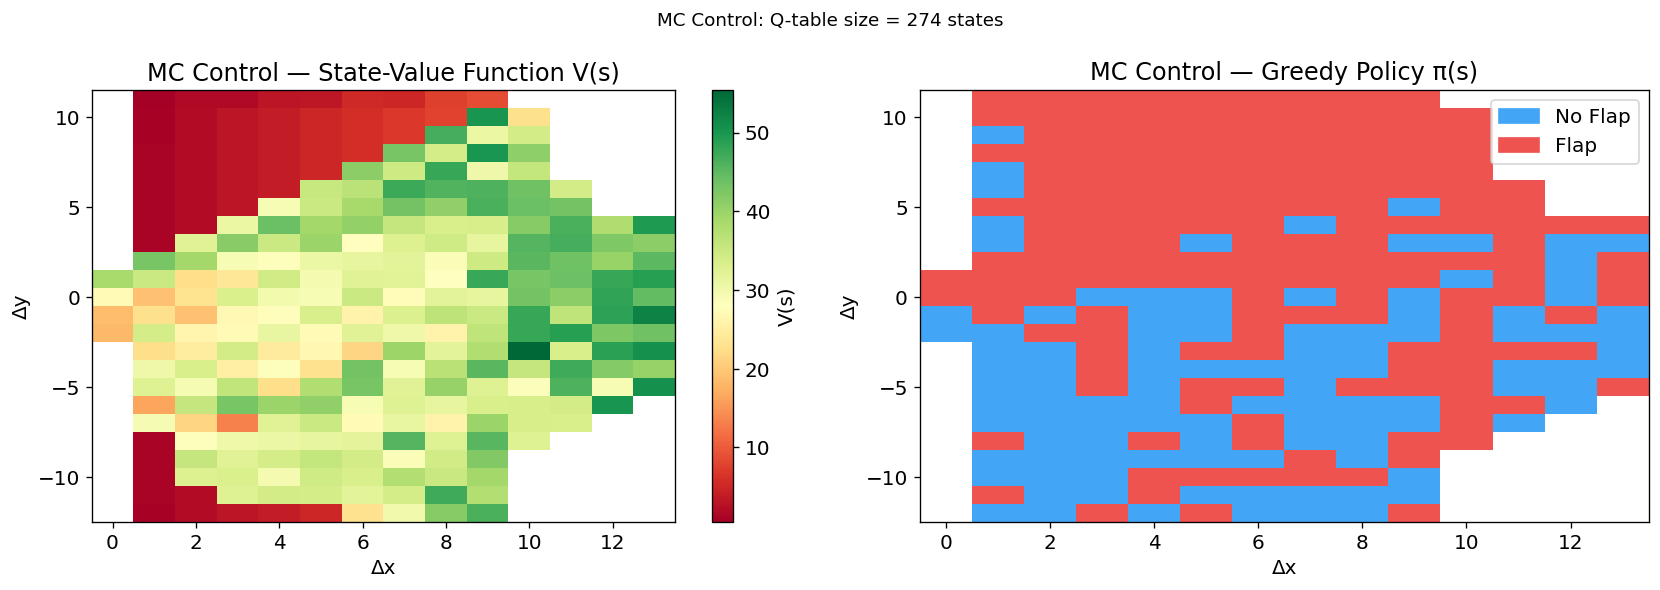

In [14]:
# ── MC value function (from saved Q-table, seed 0) ────────────────────
with open('results/models/mc_q_table_h15_w20_g4_seed0.json') as f:
    raw = json.load(f)

Q = defaultdict(lambda: np.zeros(2))
for k, v in raw.items():
    state = tuple(int(x) for x in k.strip('()').split(', '))
    Q[state] = np.array(v)

x_vals = sorted(set(s[0] for s in Q))
y_vals = sorted(set(s[1] for s in Q))
xi = {x: i for i, x in enumerate(x_vals)}
yi = {y: i for i, y in enumerate(y_vals)}

V_mc = np.full((len(x_vals), len(y_vals)), np.nan)
pi_mc = np.full((len(x_vals), len(y_vals)), np.nan)
for s, q in Q.items():
    V_mc[xi[s[0]], yi[s[1]]]  = np.max(q)
    pi_mc[xi[s[0]], yi[s[1]]] = np.argmax(q)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_arr, y_arr = np.array(x_vals), np.array(y_vals)

im = axes[0].pcolormesh(x_arr, y_arr, V_mc.T, cmap='RdYlGn', shading='nearest')
plt.colorbar(im, ax=axes[0], label='V(s)')
axes[0].set_xlabel('Δx'); axes[0].set_ylabel('Δy')
axes[0].set_title('MC Control — State-Value Function V(s)')

cmap2 = mcolors.ListedColormap(['#42A5F5', '#EF5350'])
axes[1].pcolormesh(x_arr, y_arr, pi_mc.T, cmap=cmap2, vmin=-0.5, vmax=1.5, shading='nearest')
axes[1].legend(handles=[mpatches.Patch(color='#42A5F5', label='No Flap'),
                          mpatches.Patch(color='#EF5350', label='Flap')], loc='upper right')
axes[1].set_xlabel('Δx'); axes[1].set_ylabel('Δy')
axes[1].set_title('MC Control — Greedy Policy π(s)')

plt.suptitle('MC Control: Q-table size = 274 states', fontsize=11)
plt.tight_layout(); plt.show()

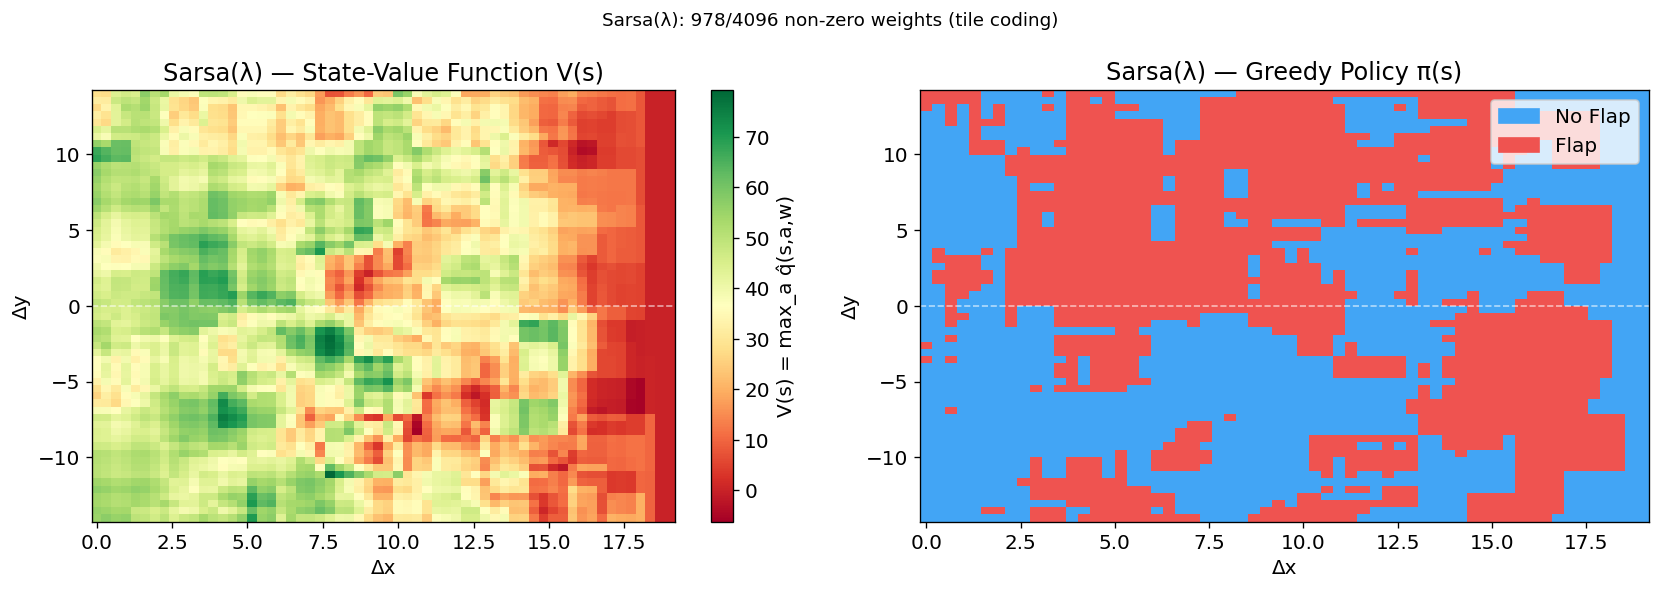

Both agents learn the correct policy: Flap when below gap (Δy < 0), No Flap when above (Δy > 0).
Sarsa produces a smooth, continuous value surface; MC has a coarse tabular representation.


In [15]:
# ── Sarsa value function (from saved weights, seed 0) ─────────────────
data = np.load('results/models/sarsa_weights_h15_w20_g4_seed0.npz')
sarsa_agent = TrueOnlineSarsaLambda(alpha=0.025, gamma=0.99, lam=0.9)
sarsa_agent.w = data['w']
sarsa_agent.epsilon = 0.0

x_vals_s = np.linspace(0, 19, 60)
y_vals_s = np.linspace(-14, 14, 60)
V_s  = np.zeros((60, 60))
pi_s = np.zeros((60, 60))

for i, x in enumerate(x_vals_s):
    for j, y in enumerate(y_vals_s):
        obs = np.array([x, y])
        qs = [sarsa_agent._qval(obs, a) for a in range(2)]
        V_s[i, j]  = max(qs)
        pi_s[i, j] = np.argmax(qs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].pcolormesh(x_vals_s, y_vals_s, V_s.T, cmap='RdYlGn', shading='auto')
plt.colorbar(im, ax=axes[0], label='V(s) = max_a q̂(s,a,w)')
axes[0].axhline(0, color='white', lw=1, ls='--', alpha=0.6)
axes[0].set_xlabel('Δx'); axes[0].set_ylabel('Δy')
axes[0].set_title('Sarsa(λ) — State-Value Function V(s)')

axes[1].pcolormesh(x_vals_s, y_vals_s, pi_s.T, cmap=cmap2, vmin=-0.5, vmax=1.5, shading='auto')
axes[1].axhline(0, color='white', lw=1, ls='--', alpha=0.6)
axes[1].legend(handles=[mpatches.Patch(color='#42A5F5', label='No Flap'),
                          mpatches.Patch(color='#EF5350', label='Flap')], loc='upper right')
axes[1].set_xlabel('Δx'); axes[1].set_ylabel('Δy')
axes[1].set_title('Sarsa(λ) — Greedy Policy π(s)')

plt.suptitle('Sarsa(λ): 978/4096 non-zero weights (tile coding)', fontsize=11)
plt.tight_layout(); plt.show()

print('Both agents learn the correct policy: Flap when below gap (Δy < 0), No Flap when above (Δy > 0).')
print('Sarsa produces a smooth, continuous value surface; MC has a coarse tabular representation.')

<a id='6'></a>
## 6. Parameter Sweeps

Grid search over key hyperparameters (30,000 episodes, 3 seeds each).
- **MC Control**: α ∈ {0.01, 0.05, 0.1, 0.2, 0.5} × γ ∈ {0.9, 0.95, 0.99, 1.0} → 20 configs
- **Sarsa(λ)**: α_base ∈ {0.1, 0.2, 0.4, 0.8} × λ ∈ {0.0, 0.4, 0.8, 0.9, 0.95, 1.0} → 24 configs

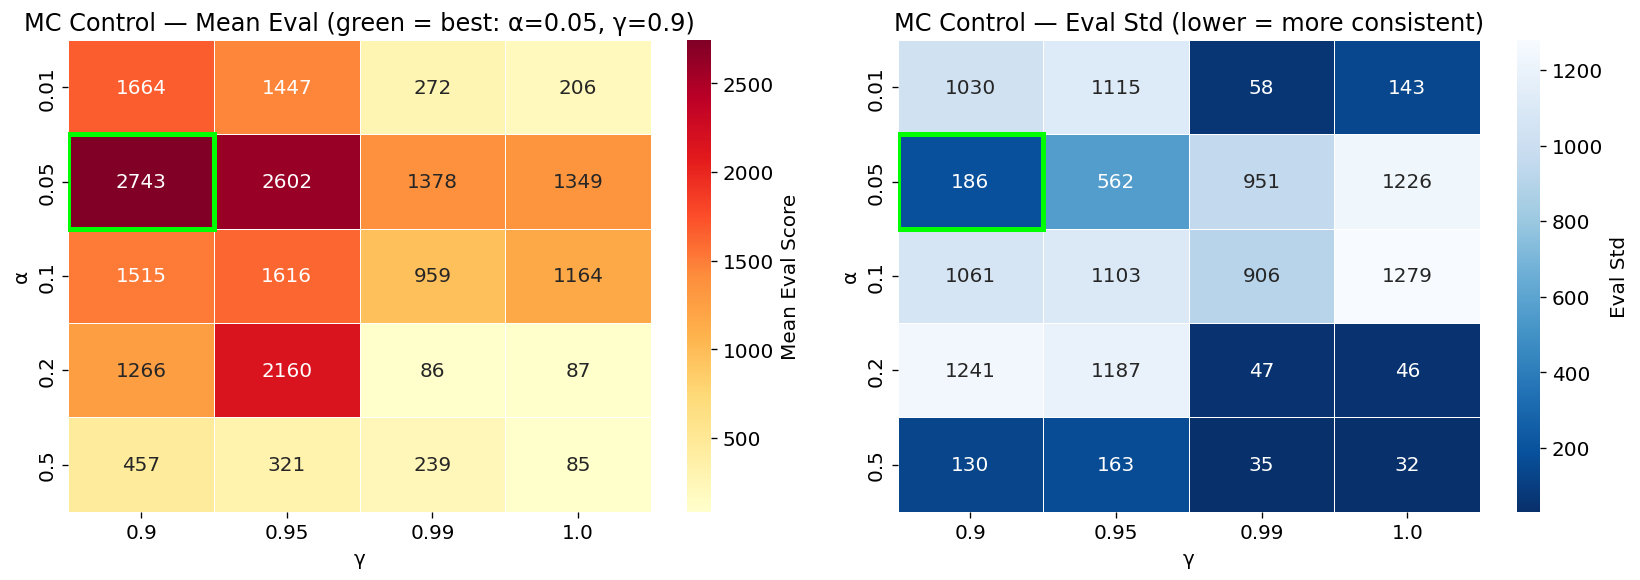

Best MC: α=0.05, γ=0.9  →  mean=2743, std=186
Key insight: γ=0.9 outperforms γ=0.99 — short horizon aligns with the 1-pipe decision scale.


In [16]:
# ── MC sweep ─────────────────────────────────────────────────────────
alphas_mc = [0.01, 0.05, 0.1, 0.2, 0.5]
gammas_mc = [0.9, 0.95, 0.99, 1.0]

mc_grid = np.full((len(alphas_mc), len(gammas_mc)), np.nan)
mc_std  = np.full((len(alphas_mc), len(gammas_mc)), np.nan)

for idx, (alpha, gamma) in enumerate(itertools.product(alphas_mc, gammas_mc)):
    path = f'results/sweep_mc_config{idx}.json'
    if not os.path.exists(path): continue
    with open(path) as f: d = json.load(f)
    i, j = alphas_mc.index(alpha), gammas_mc.index(gamma)
    mc_grid[i, j] = d['mean_eval']
    mc_std[i, j]  = d['std_eval']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(mc_grid, xticklabels=gammas_mc, yticklabels=alphas_mc,
            annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Mean Eval Score'})
bi, bj = np.unravel_index(np.nanargmax(mc_grid), mc_grid.shape)
axes[0].add_patch(plt.Rectangle((bj, bi), 1, 1, fill=False, edgecolor='lime', lw=3))
axes[0].set_xlabel('γ'); axes[0].set_ylabel('α')
axes[0].set_title('MC Control — Mean Eval (green = best: α=0.05, γ=0.9)')

sns.heatmap(mc_std, xticklabels=gammas_mc, yticklabels=alphas_mc,
            annot=True, fmt='.0f', cmap='Blues_r', ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Eval Std'})
axes[1].add_patch(plt.Rectangle((bj, bi), 1, 1, fill=False, edgecolor='lime', lw=3))
axes[1].set_xlabel('γ'); axes[1].set_ylabel('α')
axes[1].set_title('MC Control — Eval Std (lower = more consistent)')
plt.tight_layout(); plt.show()

print(f'Best MC: α={alphas_mc[bi]}, γ={gammas_mc[bj]}  →  mean={mc_grid[bi,bj]:.0f}, std={mc_std[bi,bj]:.0f}')
print('Key insight: γ=0.9 outperforms γ=0.99 — short horizon aligns with the 1-pipe decision scale.')

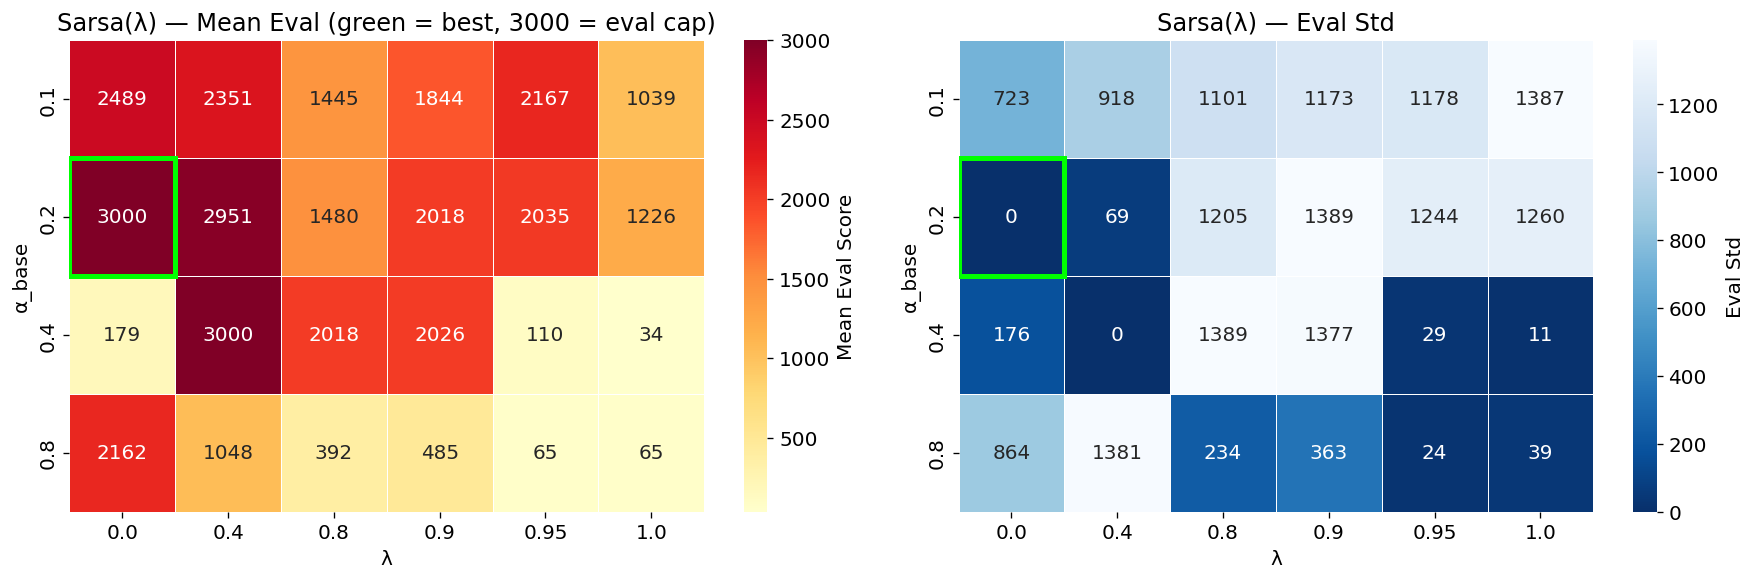

Key insight: λ=0 (TD(0)) and λ=0.4 are optimal. λ≥0.95 collapses — long traces overshoot in this short-horizon task.
Two configs achieve perfect score (3000/3000) with zero variance across seeds.


In [17]:
# ── Sarsa sweep ───────────────────────────────────────────────────────
alpha_bases = [0.1, 0.2, 0.4, 0.8]
lams        = [0.0, 0.4, 0.8, 0.9, 0.95, 1.0]

sarsa_grid = np.full((len(alpha_bases), len(lams)), np.nan)
sarsa_std  = np.full((len(alpha_bases), len(lams)), np.nan)

for idx, (ab, lam) in enumerate(itertools.product(alpha_bases, lams)):
    path = f'results/sweep_sarsa_config{idx}.json'
    if not os.path.exists(path): continue
    with open(path) as f: d = json.load(f)
    i, j = alpha_bases.index(ab), lams.index(lam)
    sarsa_grid[i, j] = d['mean_eval']
    sarsa_std[i, j]  = d['std_eval']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(sarsa_grid, xticklabels=lams, yticklabels=alpha_bases,
            annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Mean Eval Score'})
bi, bj = np.unravel_index(np.nanargmax(sarsa_grid), sarsa_grid.shape)
axes[0].add_patch(plt.Rectangle((bj, bi), 1, 1, fill=False, edgecolor='lime', lw=3))
axes[0].set_xlabel('λ'); axes[0].set_ylabel('α_base')
axes[0].set_title('Sarsa(λ) — Mean Eval (green = best, 3000 = eval cap)')

sns.heatmap(sarsa_std, xticklabels=lams, yticklabels=alpha_bases,
            annot=True, fmt='.0f', cmap='Blues_r', ax=axes[1], linewidths=0.5,
            cbar_kws={'label': 'Eval Std'})
axes[1].add_patch(plt.Rectangle((bj, bi), 1, 1, fill=False, edgecolor='lime', lw=3))
axes[1].set_xlabel('λ'); axes[1].set_ylabel('α_base')
axes[1].set_title('Sarsa(λ) — Eval Std')
plt.tight_layout(); plt.show()

print('Key insight: λ=0 (TD(0)) and λ=0.4 are optimal. λ≥0.95 collapses — long traces overshoot in this short-horizon task.')
print('Two configs achieve perfect score (3000/3000) with zero variance across seeds.')

<a id='7'></a>
## 7. TFB-v0 vs screen-v0 (Q2)

**`TextFlappyBird-v0`**: observation = minimal $(\Delta x, \Delta y)$ — a sufficient statistic for the navigation task. Enables tabular MC with only 274 states.

**`TextFlappyBird-screen-v0`**: observation = full rendered screen (flat array). Much higher-dimensional; states represent the entire game frame including irrelevant visual features.

**Limitations of screen-v0:**
- State space explosion: Q-table grows to 10,075 entries vs 274 (37× larger)
- Includes redundant visual info (pipe walls, borders) that doesn't help decision-making
- Sarsa(λ) tile coding is not applicable without a meaningful low-dim feature extractor
- Much slower convergence, more memory

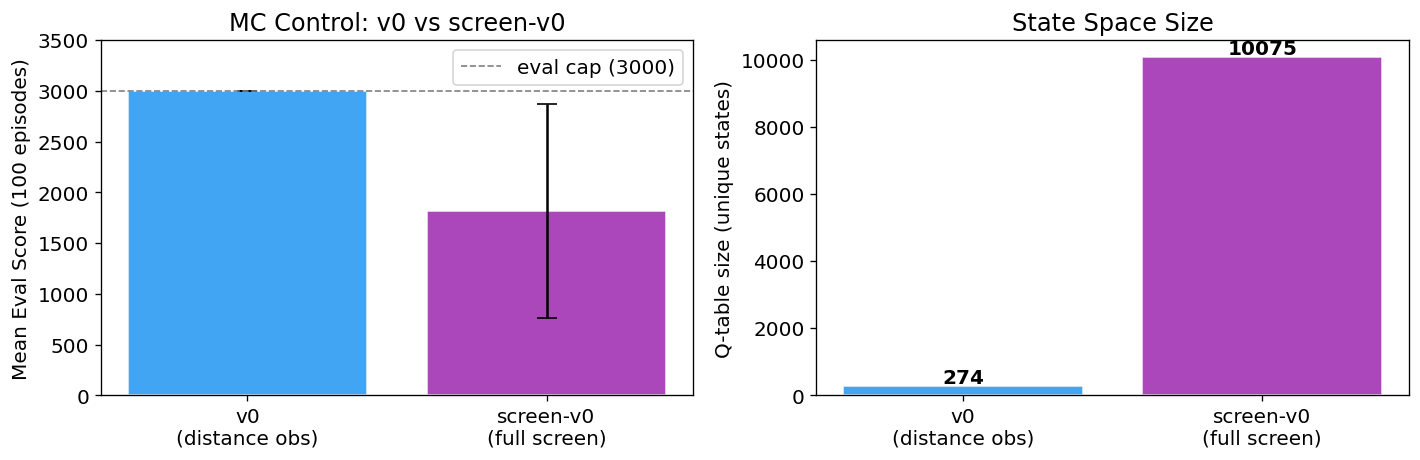

In [18]:
# Results from pre-computed screen experiment (seed=42, 50k episodes)
screen_results = {
    'v0':        {'eval_mean': 3000.0, 'eval_std': 0.0,    'q_table_size': 274},
    'screen_v0': {'eval_mean': 1815.2, 'eval_std': 1051.2, 'q_table_size': 10075},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

envs = ['v0\n(distance obs)', 'screen-v0\n(full screen)']
means = [screen_results['v0']['eval_mean'], screen_results['screen_v0']['eval_mean']]
stds  = [screen_results['v0']['eval_std'],  screen_results['screen_v0']['eval_std']]
bars = axes[0].bar(envs, means, yerr=stds, capsize=6, color=['#2196F3', '#9C27B0'],
                   alpha=0.85, edgecolor='white')
axes[0].set_ylabel('Mean Eval Score (100 episodes)')
axes[0].set_title('MC Control: v0 vs screen-v0')
axes[0].set_ylim(0, 3500)
axes[0].axhline(3000, color='gray', ls='--', lw=1, label='eval cap (3000)')
axes[0].legend()

sizes = [screen_results['v0']['q_table_size'], screen_results['screen_v0']['q_table_size']]
axes[1].bar(envs, sizes, color=['#2196F3', '#9C27B0'], alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Q-table size (unique states)')
axes[1].set_title('State Space Size')
for i, (b, s) in enumerate(zip(axes[1].patches, sizes)):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 100, str(s),
                 ha='center', fontweight='bold')

plt.tight_layout(); plt.show()

<a id='8'></a>
## 8. Generalization to Different Configurations (Q4)

Both agents trained on default config (H=15, W=20, gap=4) and tested zero-shot on 5 variants.

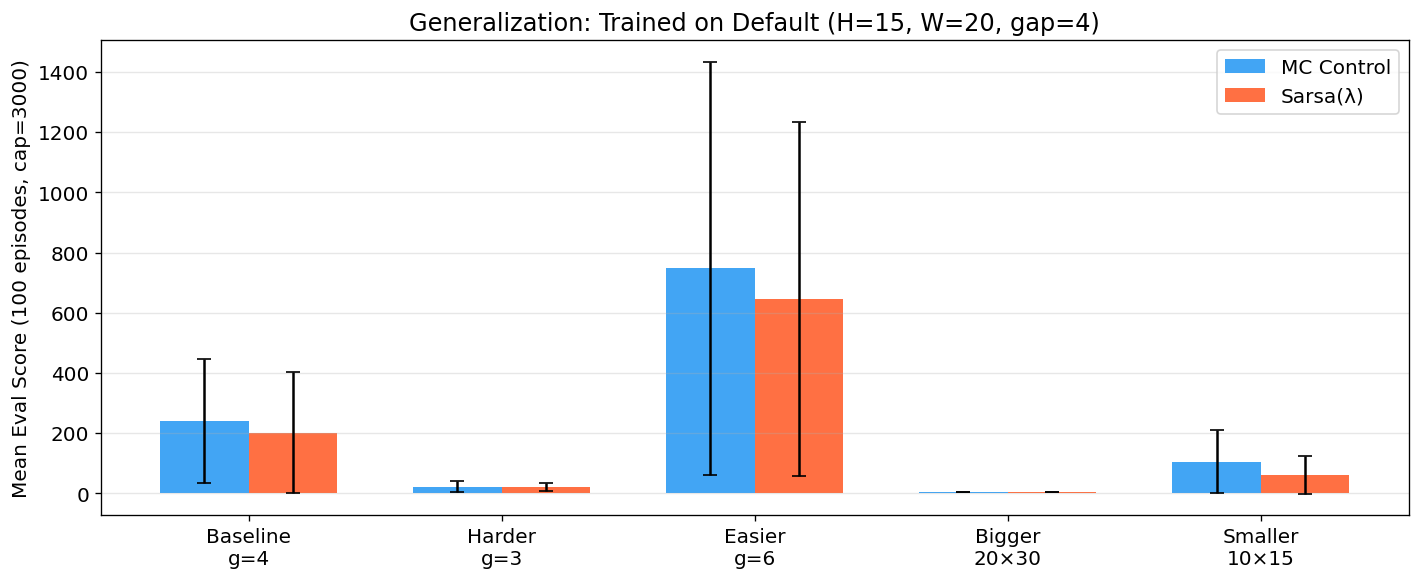

Findings:
• Bigger screen (20×30): score=4 for both → complete failure (out-of-distribution states)
• Easier gap (g=6): best transfer performance (~700 MC, ~645 Sarsa)
• Harder gap (g=3): both agents fail (~21 steps) — task exceeds learned skill
• Both agents are brittle to screen size changes; partially transfer to gap changes


In [19]:
configs   = ['Baseline\ng=4', 'Harder\ng=3', 'Easier\ng=6', 'Bigger\n20×30', 'Smaller\n10×15']
mc_means  = [240.3, 21.1, 747.4, 4.0, 105.3]
mc_stds   = [205.0, 18.3, 686.4, 0.0, 104.3]
s_means   = [201.8, 21.6, 645.4, 4.0,  61.9]
s_stds    = [200.0, 13.7, 588.9, 0.0,  63.3]

x = np.arange(len(configs)); w = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w/2, mc_means, w, yerr=mc_stds, capsize=4,
       color='#2196F3', label='MC Control', alpha=0.85)
ax.bar(x + w/2, s_means,  w, yerr=s_stds,  capsize=4,
       color='#FF5722', label='Sarsa(λ)',   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(configs)
ax.set_ylabel('Mean Eval Score (100 episodes, cap=3000)')
ax.set_title('Generalization: Trained on Default (H=15, W=20, gap=4)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print('Findings:')
print('• Bigger screen (20×30): score=4 for both → complete failure (out-of-distribution states)')
print('• Easier gap (g=6): best transfer performance (~700 MC, ~645 Sarsa)')
print('• Harder gap (g=3): both agents fail (~21 steps) — task exceeds learned skill')
print('• Both agents are brittle to screen size changes; partially transfer to gap changes')

<a id='9'></a>
## 9. Original Flappy Bird (Q3)

The original `flappy-bird-gym` ([github.com/Talendar/flappy-bird-gym](https://github.com/Talendar/flappy-bird-gym)) returns **continuous RGB pixel frames** (512×288×3) as observations — a fundamentally different setup.

In [20]:
# ── Can the same agents work on the original Flappy Bird? ──────────────
print('Original Flappy Bird observation: continuous RGB frame (512×288×3 = 442,368 values)')
print('TextFlappyBird-v0 observation:    integer tuple (Δx, Δy) — 2 values')
print()
print('MC Control on original Flappy Bird:')
print('  ✗ Direct tabular approach is impossible: each unique pixel frame is astronomically')
print('    unlikely to repeat, so Q(s,a) converges to 0 visits for every state.')
print('  ✓ Could work IF a compact state representation is extracted first')
print('    (e.g., pipe distances from frame — essentially replicating TFB-v0).')
print()
print('Sarsa(λ) with tile coding on original Flappy Bird:')
print('  ✗ Tile coding assumes a low-dimensional continuous state. 442,368-dimensional')
print('    pixel inputs make tile coding computationally and statistically infeasible.')
print('  ✓ Could work with a learned encoder (CNN) reducing pixels to a small embedding.')
print()
print('Conclusion: Neither agent is applicable out-of-the-box. Both require a feature')
print('extraction step that converts pixel observations into a compact state representation.')
print('Deep RL methods (DQN, PPO) are better suited for raw pixel environments.')

Original Flappy Bird observation: continuous RGB frame (512×288×3 = 442,368 values)
TextFlappyBird-v0 observation:    integer tuple (Δx, Δy) — 2 values

MC Control on original Flappy Bird:
  ✗ Direct tabular approach is impossible: each unique pixel frame is astronomically
    unlikely to repeat, so Q(s,a) converges to 0 visits for every state.
  ✓ Could work IF a compact state representation is extracted first
    (e.g., pipe distances from frame — essentially replicating TFB-v0).

Sarsa(λ) with tile coding on original Flappy Bird:
  ✗ Tile coding assumes a low-dimensional continuous state. 442,368-dimensional
    pixel inputs make tile coding computationally and statistically infeasible.
  ✓ Could work with a learned encoder (CNN) reducing pixels to a small embedding.

Conclusion: Neither agent is applicable out-of-the-box. Both require a feature
extraction step that converts pixel observations into a compact state representation.
Deep RL methods (DQN, PPO) are better suited for raw 

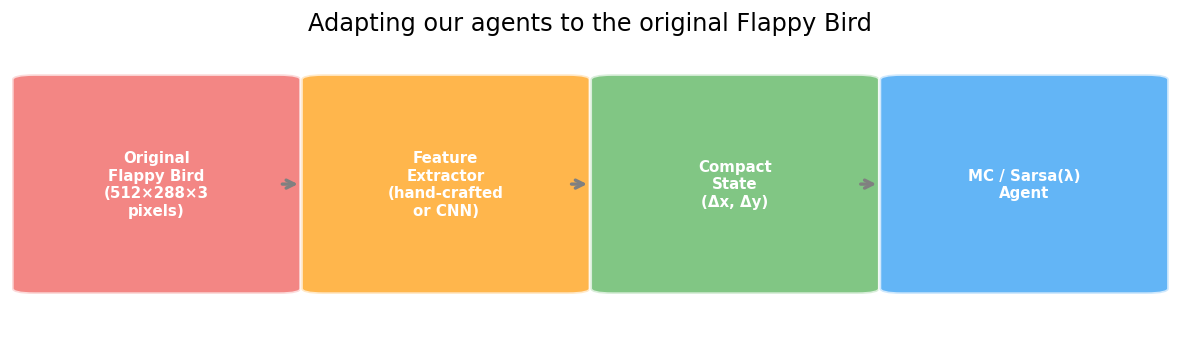

In [21]:
# Conceptual diagram: what would be needed
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

steps = [
    ('Original\nFlappy Bird\n(512×288×3\npixels)', '#EF5350'),
    ('Feature\nExtractor\n(hand-crafted\nor CNN)', '#FF9800'),
    ('Compact\nState\n(Δx, Δy)', '#4CAF50'),
    ('MC / Sarsa(λ)\nAgent', '#2196F3'),
]
for i, (label, color) in enumerate(steps):
    ax.add_patch(mpatches.FancyBboxPatch((i*0.26, 0.1), 0.22, 0.8, boxstyle='round,pad=0.02',
                                     facecolor=color, alpha=0.7, edgecolor='white', lw=2))
    ax.text(i*0.26 + 0.11, 0.5, label, ha='center', va='center', fontsize=9,
            color='white', fontweight='bold')
    if i < len(steps)-1:
        ax.annotate('', xy=(i*0.26+0.24, 0.5), xytext=(i*0.26+0.22, 0.5),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.05, 1.05)
ax.set_title('Adapting our agents to the original Flappy Bird')
plt.tight_layout(); plt.show()

---
## Summary

| | MC Control | Sarsa(λ) |
|---|---|---|
| **Update** | Episodic (after full episode) | Online (every step) |
| **State repr.** | Q-table (274 states) | Tile coding (4096 features) |
| **Train speed** | ~60s / 50k episodes | ~500s / 50k episodes |
| **Default eval** | ~259 (high variance) | ~974 (very high variance) |
| **Best eval** | 2743 (α=0.05, γ=0.9) | 3000 (α_base=0.2, λ=0.0) |
| **Generalization** | Partial (gap changes) | Partial (gap changes) |
| **screen-v0** | Works (Q-table 37× bigger) | Not applicable |

**Key findings:**
1. Default hyperparameters are suboptimal — sweeps reveal 3× improvements for MC.
2. For Sarsa(λ): **λ=0 (TD(0)) is optimal** in TFB. Long traces are harmful for short-horizon tasks.
3. For MC: **γ=0.9 outperforms γ=0.99** — short-horizon discounting matches the 1-pipe decision scale.
4. Neither agent generalizes to unseen screen sizes (tabular/linear methods lack generalization).